# 02 · Distribuciones y cumplimiento de la norma

**Preguntas:**
- ¿En qué rangos se mueve cada parámetro, y cómo cambia de un sensor a otro?
- ¿Qué tanto se cumple la norma de calidad del agua potable, en operación normal y durante eventos?
- ¿Se parecen los tres periodos (entrenamiento, validación y prueba), o el modelo va a ver en la
  prueba condiciones distintas a las que aprendió?

Se usan solo las **lecturas válidas**, según lo encontrado en el notebook 01 (`src/calidad.py`):
se descartan las lecturas con falla de sensor identificada, las tomadas con la tubería sin presión
(menos de 1 m) y las que están fuera del rango físico posible.

**Norma de referencia:** Decreto 38924-S, Reglamento para la Calidad del Agua Potable:

| Parámetro | Rango |
|---|---|
| Cloro residual libre | 0,3 – 1,0 mg/L |
| Turbiedad | valor recomendado 1 UNT, máximo admisible 5 UNT |
| pH | 6,5 – 8,5 |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import carga, calidad
from src.graficos import estilo, guardar, COLORES, GRIS

estilo()
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

crudo = carga.cargar_todo()
t = calidad.lecturas_validas(crudo)
S = carga.sensores(t)
PARAM = ["CL2", "TEMP", "TURB", "PH", "P"]
ETIQ = {"CL2": "Cloro libre (mg/L)", "TEMP": "Temperatura (°C)", "TURB": "Turbidez (UNT)",
        "PH": "pH", "P": "Presión (m)"}

descartadas = {p: (crudo[[f"{p}_{n}" for n in S]].notna().values & t[[f"{p}_{n}" for n in S]].isna().values).mean() * 100
               for p in calidad.CALIDAD}
print("Lecturas descartadas por la limpieza:", {p: f"{x:.2f} %" for p, x in descartadas.items()})

valores = lambda p, d=t: d[[f"{p}_{n}" for n in S]].values.ravel()
evento = t[[f"evento_{n}" for n in S]].values.ravel()     # tipo de evento visible en cada sensor

Lecturas descartadas por la limpieza: {'CL2': '0.16 %', 'TEMP': '0.08 %', 'TURB': '0.22 %', 'PH': '0.03 %'}


## 1. Resumen estadístico

Todas las lecturas válidas de los 21 sensores juntas, para tener una idea de los rangos típicos.

In [2]:
resumen = {}
for p in PARAM:
    x = pd.Series(valores(p)).dropna()
    resumen[ETIQ[p]] = x.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
resumen = pd.DataFrame(resumen).T.drop(columns="count")
resumen

,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Cloro libre (mg/L),0.657,0.208,0.00,0.11,0.22,0.54,0.70,0.79,0.95,1.07,1.42
Temperatura (°C),25.275,1.257,21.60,22.70,23.20,24.30,25.30,26.30,27.20,27.50,28.00
Turbidez (UNT),0.837,1.138,0.00,0.37,0.42,0.50,0.58,0.83,1.78,3.81,21.53
pH,7.251,0.161,5.51,6.69,7.08,7.21,7.26,7.31,7.37,7.55,8.85
Presión (m),47.976,19.648,-0.10,2.80,8.00,34.60,48.20,60.80,78.20,88.00,110.40


## 2. Distribución de cada parámetro

Las líneas grises marcan los límites de la norma. La turbidez se muestra en escala logarítmica
porque casi siempre está cerca de 0,5 UNT, pero en algunos eventos sube por encima de 10.

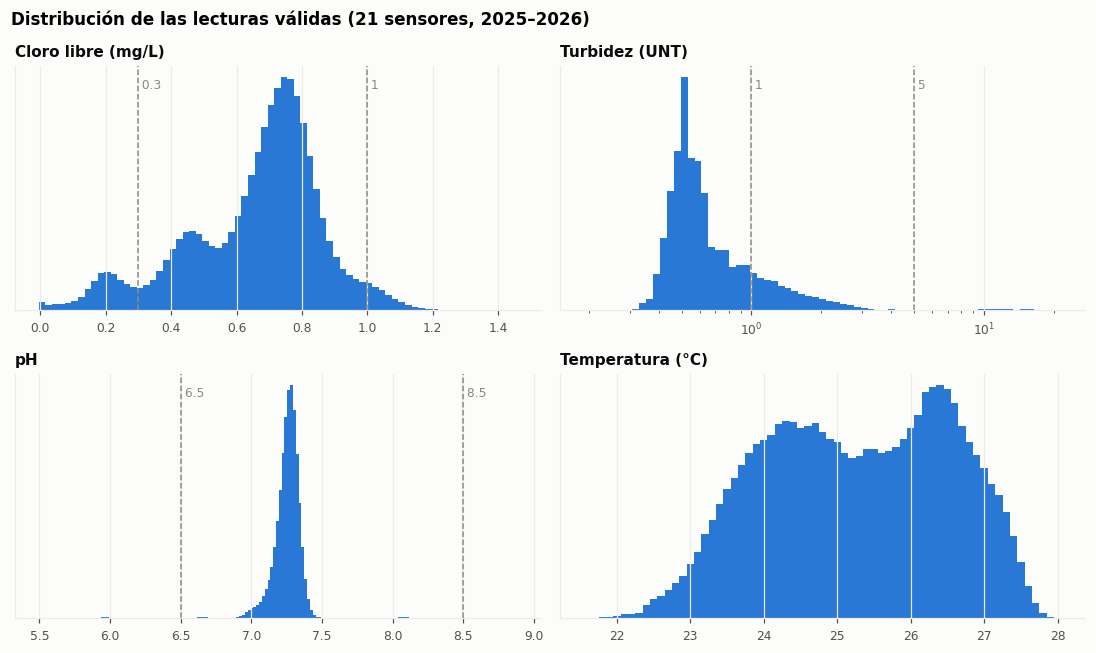

In [3]:
lineas = {"CL2": [0.3, 1.0], "TURB": [1.0, 5.0], "PH": [6.5, 8.5], "TEMP": []}
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, p in zip(axes.ravel(), ["CL2", "TURB", "PH", "TEMP"]):
    x = pd.Series(valores(p)).dropna().astype(float).round(3)   # quita el error de redondeo de float32
    if p == "TURB":
        bins = np.logspace(np.log10(max(x[x > 0].min(), 0.05)), np.log10(x.max()), 70)
        ax.set_xscale("log")
    else:
        # ancho múltiplo de la resolución del sensor y bordes entre dos valores posibles
        paso, resol = {"CL2": (0.02, 0.01), "PH": (0.02, 0.01), "TEMP": (0.1, 0.1)}[p]
        bins = np.floor(x.min() / paso) * paso - resol / 2 + paso * np.arange(int((x.max() - x.min()) / paso) + 3)
    ax.hist(x, bins=bins, color=COLORES[0])
    for v in lineas[p]:
        ax.axvline(v, color=GRIS, ls="--", lw=1)
        ax.text(v, ax.get_ylim()[1] * 0.95, f" {v:g}", color=GRIS, fontsize=8, va="top")
    ax.set_title(ETIQ[p], fontsize=10)
    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
fig.suptitle("Distribución de las lecturas válidas (21 sensores, 2025–2026)", x=0.01, ha="left",
             fontsize=11, fontweight="bold")
fig.tight_layout()
guardar(fig, "02_distribuciones"); plt.show()

## 3. Diferencias entre sensores

El cloro se consume a medida que el agua recorre la red, así que se espera que los sensores más
lejanos de la fuente (o con agua más "vieja") tengan menos cloro. Los sensores se ordenan por su
cloro mediano.

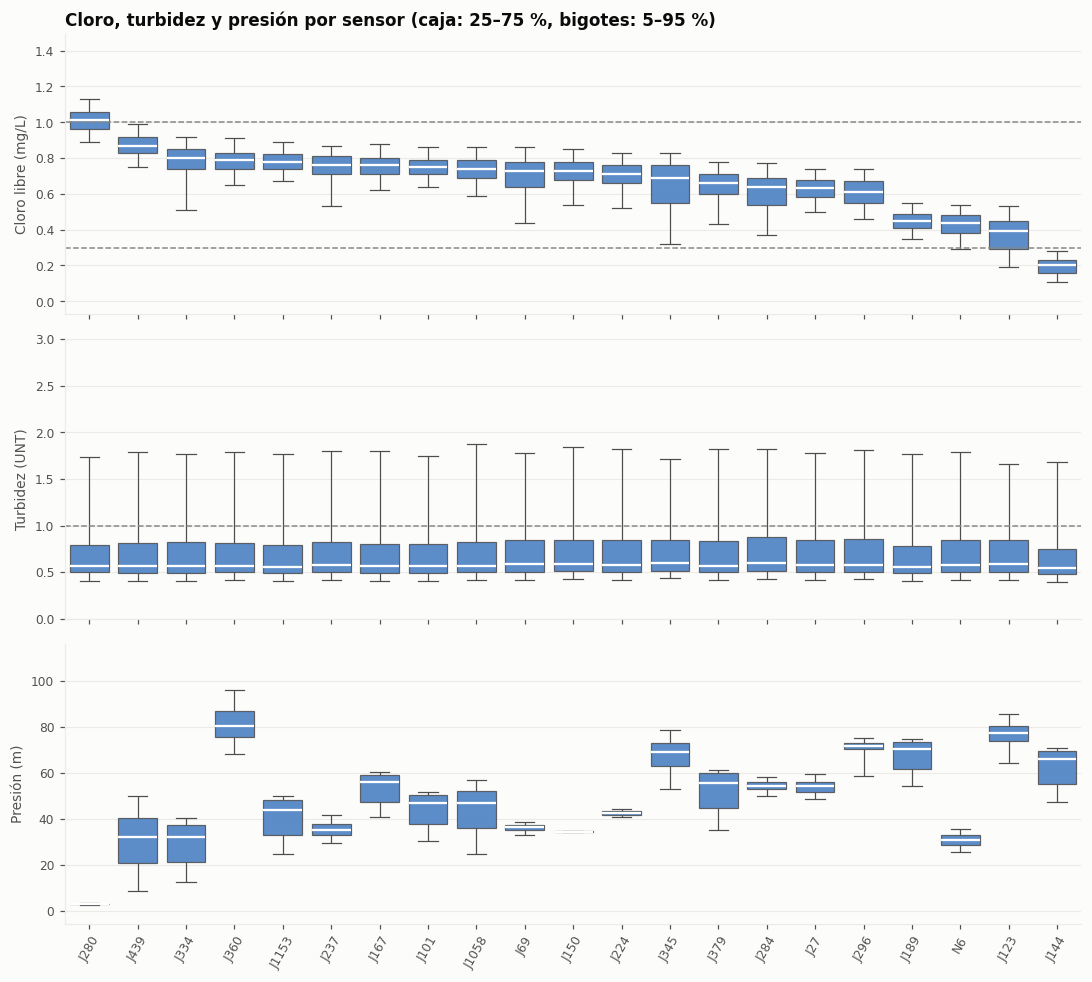

In [4]:
largo = carga.larga(t)
orden = largo.groupby("sensor")["CL2"].median().sort_values(ascending=False).index

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, p in zip(axes, ["CL2", "TURB", "P"]):
    sns.boxplot(data=largo, x="sensor", y=p, order=orden, ax=ax, color=COLORES[0],
                fliersize=0, linewidth=0.8, whis=(5, 95),
                boxprops={"alpha": 0.85}, medianprops={"color": "white", "linewidth": 1.5})
    ax.set_ylabel(ETIQ[p]); ax.set_xlabel("")
    for v in lineas.get(p, []):
        ax.axhline(v, color=GRIS, ls="--", lw=1)
    if p == "TURB":
        ax.set_ylim(0, 3)
axes[0].set_title("Cloro, turbidez y presión por sensor (caja: 25–75 %, bigotes: 5–95 %)")
axes[-1].tick_params(axis="x", rotation=60)
fig.tight_layout()
guardar(fig, "02_por_sensor"); plt.show()

In [5]:
por_sensor = pd.DataFrame({
    "cloro mediano": [np.nanmedian(t[f"CL2_{n}"]) for n in S],
    "turbidez mediana": [np.nanmedian(t[f"TURB_{n}"]) for n in S],
    "presión mediana": [np.nanmedian(t[f"P_{n}"]) for n in S],
}, index=S).loc[orden]
por_sensor.T

sensor,J280,J439,J334,J360,J1153,J237,J167,J101,J1058,J69,J150,J224,J345,J379,J284,J27,J296,J189,N6,J123,J144
cloro mediano,1.01,0.87,0.80,0.79,0.78,0.76,0.76,0.75,0.74,0.73,0.73,0.71,0.69,0.66,0.64,0.63,0.61,0.45,0.44,0.39,0.20
turbidez mediana,0.57,0.57,0.57,0.57,0.56,0.58,0.57,0.57,0.57,0.59,0.59,0.58,0.60,0.57,0.60,0.58,0.58,0.56,0.58,0.59,0.55
presión mediana,3.00,32.20,32.00,80.10,43.90,35.10,55.80,47.00,46.80,36.20,34.40,42.50,68.80,55.40,54.30,54.00,71.40,70.30,30.60,77.20,65.90


## 4. Cumplimiento de la norma

Porcentaje de lecturas válidas fuera de la norma, por sensor. Se separa la **operación normal**
(sin evento visible en ese sensor) de los **eventos** (contaminación, falla de cloración, turbidez
en la fuente o falla de pH), porque responden a preguntas distintas: la primera dice cómo funciona
la red en el día a día; la segunda, qué tan graves son los eventos.

In [6]:
def fuera_de_norma(d, mascara=None):
    filas = {}
    for n in S:
        cl, tu, ph = d[f"CL2_{n}"], d[f"TURB_{n}"], d[f"PH_{n}"]
        m = np.ones(len(d), bool) if mascara is None else mascara(n)
        pct = lambda cond, x: 100 * (cond & x.notna() & m).sum() / max((x.notna() & m).sum(), 1)
        filas[n] = {"cloro < 0,3": pct(cl < 0.3, cl), "cloro > 1,0": pct(cl > 1.0, cl),
                    "turbidez > 1": pct(tu > 1, tu), "turbidez > 5": pct(tu > 5, tu),
                    "pH fuera de 6,5–8,5": pct((ph < 6.5) | (ph > 8.5), ph)}
    return pd.DataFrame(filas).T

normal = fuera_de_norma(t, lambda n: t[f"evento_{n}"].values == 0)
eventos = fuera_de_norma(t, lambda n: t[f"evento_{n}"].values > 0)

total = pd.DataFrame({
    "operación normal": [100 * np.nanmean(np.where(evento == 0, c, np.nan)) for c in [
        np.where(np.isnan(valores("CL2")), np.nan, valores("CL2") < 0.3),
        np.where(np.isnan(valores("CL2")), np.nan, valores("CL2") > 1.0),
        np.where(np.isnan(valores("TURB")), np.nan, valores("TURB") > 1),
        np.where(np.isnan(valores("TURB")), np.nan, valores("TURB") > 5),
        np.where(np.isnan(valores("PH")), np.nan, (valores("PH") < 6.5) | (valores("PH") > 8.5))]],
    "durante eventos": [100 * np.nanmean(np.where(evento > 0, c, np.nan)) for c in [
        np.where(np.isnan(valores("CL2")), np.nan, valores("CL2") < 0.3),
        np.where(np.isnan(valores("CL2")), np.nan, valores("CL2") > 1.0),
        np.where(np.isnan(valores("TURB")), np.nan, valores("TURB") > 1),
        np.where(np.isnan(valores("TURB")), np.nan, valores("TURB") > 5),
        np.where(np.isnan(valores("PH")), np.nan, (valores("PH") < 6.5) | (valores("PH") > 8.5))]],
}, index=normal.columns)
print(f"Lecturas en operación normal: {100 * (evento == 0).mean():.1f} %  ·  durante eventos: {100 * (evento > 0).mean():.1f} %")
total

Lecturas en operación normal: 94.0 %  ·  durante eventos: 6.0 %


,operación normal,durante eventos
"cloro < 0,3",5.978,33.586
"cloro > 1,0",2.810,1.295
turbidez > 1,16.084,39.102
turbidez > 5,0.000,14.076
"pH fuera de 6,5–8,5",0.000,13.110


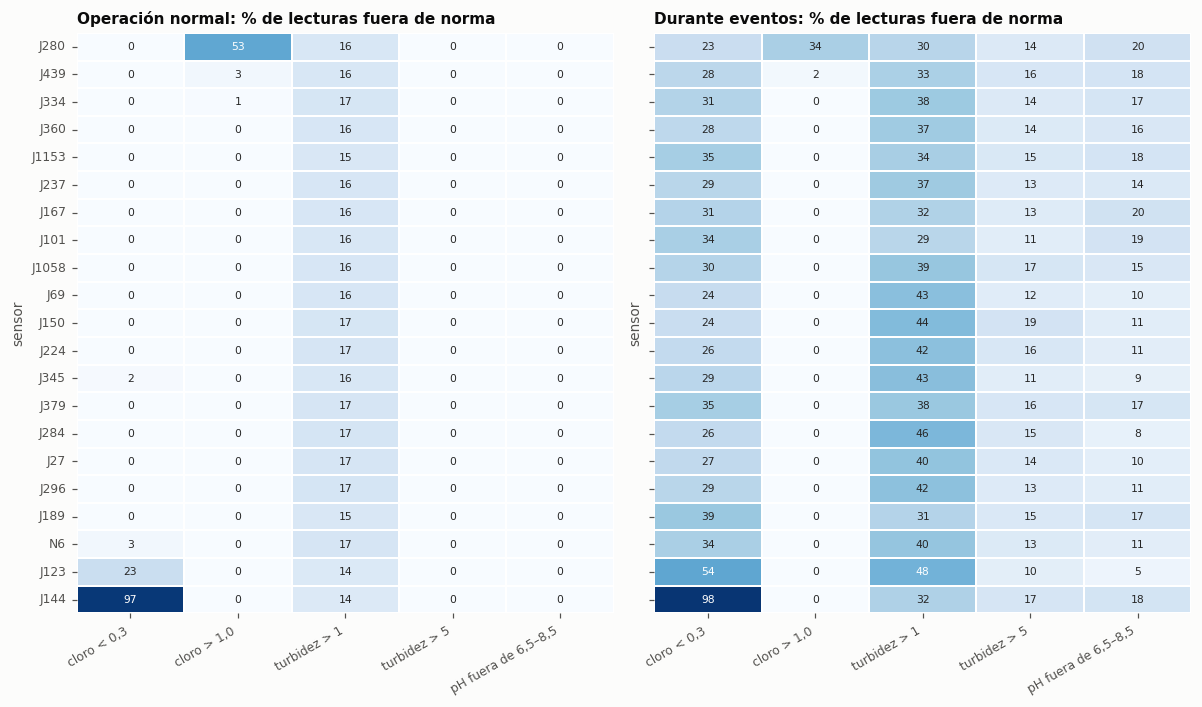

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6.5), sharey=True)
for ax, (nombre, d) in zip(axes, [("Operación normal", normal), ("Durante eventos", eventos)]):
    sns.heatmap(d.loc[orden], annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, cbar=False,
                linewidths=1, linecolor="white", ax=ax, annot_kws={"fontsize": 7})
    ax.set_title(f"{nombre}: % de lecturas fuera de norma", fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.grid(False)
fig.tight_layout()
guardar(fig, "02_cumplimiento_norma"); plt.show()

## 5. Cómo se ve cada tipo de evento

Distribución de cloro, turbidez y pH según el tipo de evento visible en el sensor. Esto anticipa qué
tan fácil será para un modelo distinguir cada evento de la operación normal.

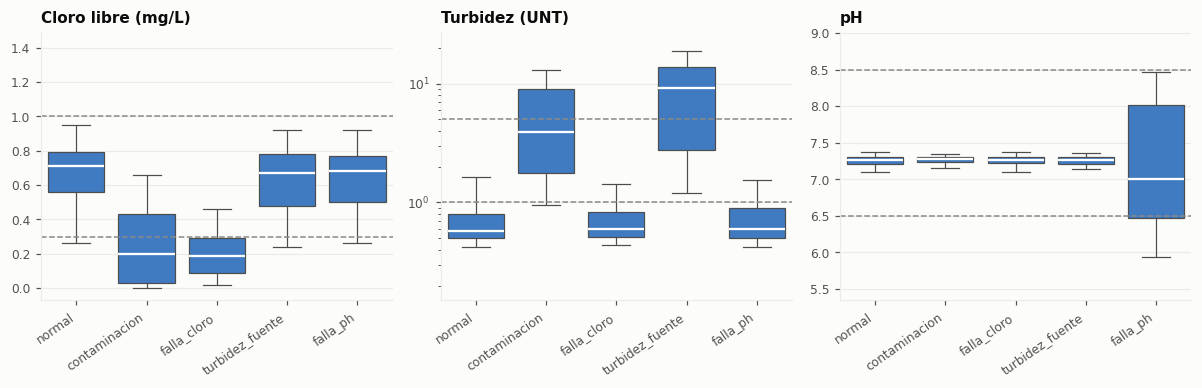

In [8]:
orden_ev = ["normal", "contaminacion", "falla_cloro", "turbidez_fuente", "falla_ph"]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, p in zip(axes, ["CL2", "TURB", "PH"]):
    sns.boxplot(data=largo, x="evento", y=p, order=orden_ev, ax=ax, color=COLORES[0],
                fliersize=0, linewidth=0.8, whis=(5, 95),
                medianprops={"color": "white", "linewidth": 1.5})
    ax.set_title(ETIQ[p], fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
    for v in lineas.get(p, []):
        ax.axhline(v, color=GRIS, ls="--", lw=1)
    if p == "TURB":
        ax.set_yscale("log")
fig.tight_layout()
guardar(fig, "02_por_tipo_evento"); plt.show()

In [9]:
largo.groupby("evento")[["CL2", "TURB", "PH", "TEMP"]].median().loc[orden_ev]

,CL2,TURB,PH,TEMP
evento,,,,
normal,0.71,0.57,7.26,25.3
contaminacion,0.20,3.91,7.28,25.7
falla_cloro,0.19,0.60,7.27,24.8
turbidez_fuente,0.67,9.16,7.26,24.3
falla_ph,0.68,0.60,7.00,25.3


## 6. Diferencias entre entrenamiento, validación y prueba

Las tres particiones son periodos consecutivos, no una mezcla al azar. Eso es lo correcto para
series de tiempo (el modelo no puede ver el futuro), pero tiene una consecuencia: si los periodos
tienen condiciones distintas, el modelo se evalúa en condiciones que vio poco al entrenar.

In [10]:
lluvia_diaria = t["lluvia_mm_h"].groupby(t["particion"]).apply(lambda x: x.sum() / 4 / (len(x) / 96))
comparacion = pd.DataFrame({part: {
    "meses": {"entrenamiento": "ene 2025 – abr 2026", "validacion": "may – ago 2026",
              "prueba": "sep – dic 2026"}[part],
    "lluvia media (mm/día)": lluvia_diaria[part],
    "cloro medio (mg/L)": np.nanmean(valores("CL2", t[t.particion == part])),
    "temperatura media (°C)": np.nanmean(valores("TEMP", t[t.particion == part])),
    "turbidez media (UNT)": np.nanmean(valores("TURB", t[t.particion == part])),
    "turbidez p95 (UNT)": np.nanpercentile(valores("TURB", t[t.particion == part]), 95),
    "pH medio": np.nanmean(valores("PH", t[t.particion == part])),
    "% del tiempo con evento visible": 100 * (t.loc[t.particion == part, "evento_visible"] > 0).mean(),
} for part in carga.PARTICIONES}).T
comparacion

,meses,lluvia media (mm/día),cloro medio (mg/L),temperatura media (°C),turbidez media (UNT),turbidez p95 (UNT),pH medio,% del tiempo con evento visible
entrenamiento,ene 2025 – abr 2026,4.542,0.66,25.507,0.812,1.74,7.26,21.147
validacion,may – ago 2026,6.459,0.642,25.606,0.786,1.63,7.234,17.039
prueba,sep – dic 2026,8.431,0.661,24.016,0.984,2.05,7.233,24.161


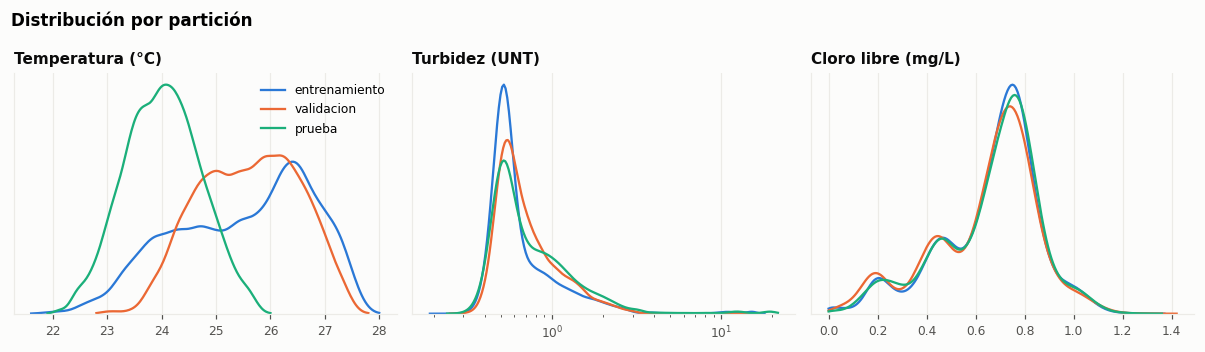

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, p in zip(axes, ["TEMP", "TURB", "CL2"]):
    for k, part in enumerate(carga.PARTICIONES):
        x = pd.Series(valores(p, t[t.particion == part])).dropna()
        if p == "TURB":
            x = x[x > 0]
        sns.kdeplot(x, ax=ax, color=COLORES[k], label=part, lw=1.5, log_scale=(p == "TURB"),
                    cut=0, bw_adjust=1.5)
    ax.set_title(ETIQ[p], fontsize=10); ax.set_xlabel(""); ax.set_yticks([]); ax.set_ylabel("")
    ax.grid(axis="y", visible=False)
axes[0].legend()
fig.suptitle("Distribución por partición", x=0.01, ha="left", fontsize=11, fontweight="bold")
fig.tight_layout()
guardar(fig, "02_por_particion"); plt.show()

## 7. Relación entre parámetros

Correlación de Spearman (por rangos, robusta a valores extremos) entre los parámetros de un mismo
sensor, la lluvia y el caudal de la fuente. Se calcula **dentro de cada sensor** y se reporta la
mediana de los 21 sensores. Si se juntaran todos los sensores en una sola tabla, la correlación
mezclaría las diferencias *entre* sensores (por ejemplo, los sensores con más presión resultan ser
también los más lejanos, con menos cloro) con las relaciones *dentro* de cada uno, que son las que
le sirven a un modelo.

La lluvia se toma en el mismo instante; su efecto con retraso se analiza en el notebook 04.

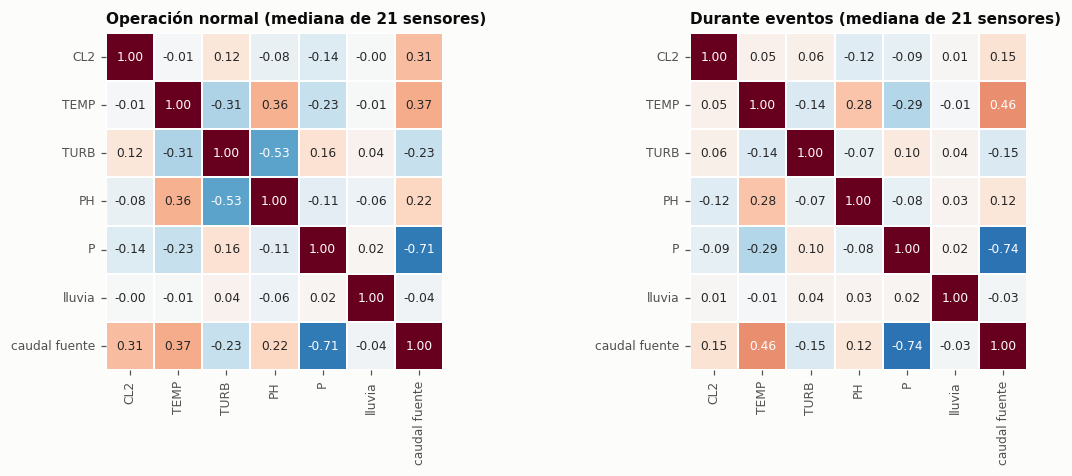

In [12]:
def correlaciones(mascara_evento):
    por_sensor = []
    for n in S:
        d = t[[f"{p}_{n}" for p in PARAM] + ["lluvia_mm_h", "Q_R1"]].copy()
        d.columns = PARAM + ["lluvia", "caudal fuente"]
        d = d[mascara_evento(t[f"evento_{n}"].values)]
        por_sensor.append(d.corr(method="spearman").values)
    return pd.DataFrame(np.nanmedian(np.stack(por_sensor), axis=0), index=d.columns, columns=d.columns)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (nombre, m) in zip(axes, [("Operación normal", lambda e: e == 0), ("Durante eventos", lambda e: e > 0)]):
    c = correlaciones(m)
    sns.heatmap(c, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0, cbar=False,
                square=True, linewidths=1, linecolor="white", ax=ax, annot_kws={"fontsize": 8})
    ax.set_title(f"{nombre} (mediana de 21 sensores)", fontsize=10); ax.grid(False)
fig.tight_layout()
guardar(fig, "02_correlaciones"); plt.show()

También interesa si los sensores se mueven juntos: si la turbidez de todos sube a la vez, por
ejemplo, el pronóstico de un sensor puede apoyarse en los demás.

In [13]:
entre = pd.DataFrame({p: [t[[f"{p}_{n}" for n in S]].corr(method="spearman").values[np.triu_indices(len(S), 1)].mean()]
                      for p in calidad.CALIDAD}, index=["correlación media entre pares de sensores"]).T
entre

,correlación media entre pares de sensores
CL2,0.284
TEMP,0.945
TURB,0.764
PH,0.679


## 8. Conclusiones e implicaciones para el modelo

**Lo que dicen los datos**

1. **La calidad del agua es buena en el día a día, con una excepción clara.** En operación normal el
   pH nunca sale de norma y la turbidez nunca pasa de 5 UNT. El cloro cumple en casi todos los
   sensores, salvo en los extremos de la red: **J144 está por debajo de 0,3 mg/L el 97 % del tiempo
   y J123 el 23 %**, aun sin ningún evento. Ahí el agua llega con el cloro consumido. Es un
   incumplimiento crónico de la red, no un evento, y el modelo lo va a ver como "lo normal" de esos
   sensores.
2. **A la salida de la fuente el cloro está justo en el límite superior.** J280 tiene una mediana de
   1,01 mg/L y el 53 % de sus lecturas supera 1,0 mg/L. El resto de la red baja de ahí a medida que
   el agua avanza: de 0,87 mg/L en J439 a 0,20 mg/L en J144.
3. **El cloro es propio de cada sensor; la turbidez, la temperatura y el pH son de toda la red.** La
   turbidez mediana es casi idéntica en los 21 sensores (0,55–0,60 UNT), y los sensores se mueven
   juntos: la correlación media entre pares es 0,95 en temperatura, 0,76 en turbidez y 0,68 en pH,
   pero solo 0,28 en cloro. Esos tres parámetros vienen de la fuente y viajan por la red; el cloro
   depende además del recorrido y del consumo locales.
4. **La turbidez supera el valor recomendado (1 UNT) el 16 % del tiempo en operación normal**, igual
   en todos los sensores. Viene de la fuente, no de la red.
5. **Cada tipo de evento tiene una firma distinta:**
   - **contaminación:** baja el cloro (mediana 0,20 mg/L) y sube la turbidez (3,9 UNT);
   - **falla de cloración:** baja el cloro (0,19 mg/L) sin cambiar la turbidez;
   - **turbidez en la fuente:** sube mucho la turbidez (9,2 UNT) con poco efecto en el cloro;
   - **falla de pH:** mueve el pH hacia arriba o hacia abajo, sin tocar el cloro ni la turbidez.

   Contaminación y falla de cloración se parecen en el cloro: la turbidez es lo que las separa.
6. **Las relaciones dentro de cada sensor son moderadas:**
   - el caudal de la fuente tiene una relación fuerte e inversa con la presión (−0,71): a más
     consumo, menos presión;
   - más caudal también trae agua más fresca, con más cloro (+0,31);
   - turbidez y pH se mueven en sentido contrario (−0,53).

   La lluvia, tomada en el mismo instante, casi no se relaciona con nada. Su efecto llega con
   retraso, y eso se mide en el notebook 04.
7. **Los periodos no son iguales.** La prueba (sep–dic 2026) es la época más lluviosa: 8,4 mm/día,
   contra 4,5 en entrenamiento y 6,5 en validación. Por eso tiene agua más fría (24,0 °C contra
   25,5) y más turbia (p95 de 2,1 UNT contra 1,7), además de más tiempo con eventos (24 %). El
   entrenamiento sí incluye esos meses del año anterior (sep–dic 2025), pero la validación
   (may–ago) es más cálida y más seca que la prueba.

**Qué implica para el modelo**

- **Normalizar por sensor, sobre todo el cloro.** Un mismo valor (0,25 mg/L) es normal en J144 y una
  alarma en J439. El modelo necesita saber de qué sensor viene cada lectura, por ejemplo con una
  identificación del sensor o con datos centrados en la media de cada uno.
- **Aprovechar que turbidez, temperatura y pH son de toda la red.** El pronóstico de un sensor
  puede usar los de los demás, en especial los más cercanos a la fuente, que ven los cambios antes.
- **La turbidez no se puede pronosticar sin la lluvia y con su retraso.** Es la variable donde los
  datos climáticos (IMN y pronósticos) más deberían ayudar.
- **Para detectar eventos, mirar varios parámetros a la vez.** El cloro solo no distingue una
  contaminación de una falla de cloración; la turbidez sí.
- **Cuidado al elegir umbrales con la validación.** La validación es más seca que la prueba, así
  que un umbral de alarma ajustado ahí puede comportarse distinto en la época lluviosa. Conviene
  revisar los resultados por época (seca y lluviosa), no solo el promedio.
- **La meta del 80 % debe medirse aparte en operación normal y durante eventos.** El 94 % de las
  lecturas son de operación normal, así que un promedio general queda dominado por los días
  tranquilos, que son los más fáciles de pronosticar.